        Diabetes_012  HighBP  HighChol  CholCheck  ...  Sex   Age  Education  Income
0                0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     3.0
1                0.0     0.0       0.0        0.0  ...  0.0   7.0        6.0     1.0
2                0.0     1.0       1.0        1.0  ...  0.0   9.0        4.0     8.0
3                0.0     1.0       0.0        1.0  ...  0.0  11.0        3.0     6.0
4                0.0     1.0       1.0        1.0  ...  0.0  11.0        5.0     4.0
...              ...     ...       ...        ...  ...  ...   ...        ...     ...
253675           0.0     1.0       1.0        1.0  ...  1.0   5.0        6.0     7.0
253676           2.0     1.0       1.0        1.0  ...  0.0  11.0        2.0     4.0
253677           0.0     0.0       0.0        1.0  ...  0.0   2.0        5.0     2.0
253678           0.0     1.0       0.0        1.0  ...  1.0   7.0        5.0     1.0
253679           2.0     1.0       1.0        1.0  ...  0.0   9.0

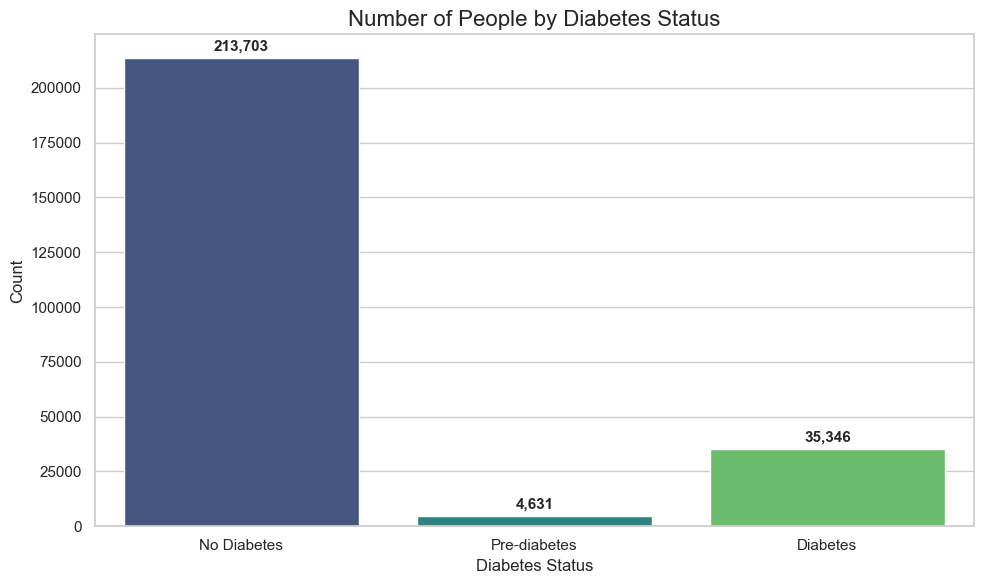

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
###########################what Data Contain #################################################
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
print(df)
diabetes_map = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}
df['Diabetes_Status'] = df['Diabetes_012'].map(diabetes_map)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,  # Assign x to hue
    palette='viridis',
    legend=False              # Hide the extra legend box
)

# Add labels and title
plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the count numbers on top of each bar for better readability
for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_bar_chart.png')
plt.show()

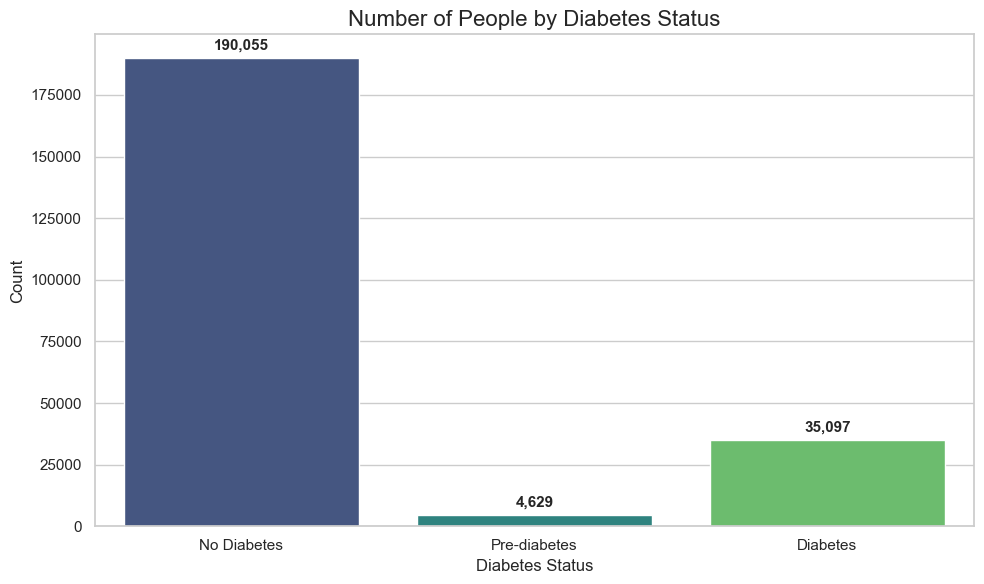

In [4]:
#cleaning Data

df.dropna(inplace= True)
df.drop_duplicates(inplace = True)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
## Data does not contain empty cell
##############################plot after remove duplicates####################################
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_after_re_dublicates.png')
plt.show()

In [ ]:
x = df.drop(columns=['Diabetes_012','Diabetes_Status'])
y = df['Diabetes_012']
df=df.drop(columns=['Diabetes_Status'])
X_train_val, X_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # Fixed seed for reproducibility
    stratify=y         # Maintain class proportions
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,     # 12.5% of the 80% is 10% of the original
    random_state=42,
    stratify=y_train_val
)

def print_distribution(y_set, name):
    counts = y_set.value_counts().sort_index()
    percentages = y_set.value_counts(normalize=True).sort_index() * 100
    labels = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}

    print(f"--- {name} Set ---")
    for val in [0.0, 1.0, 2.0]:
        print(f"{labels[val]}: {int(counts[val])} samples ({percentages[val]:.2f}%)")
    print("-" * 30)

print_distribution(y_train, "Training (70%)")
print_distribution(y_val, "Validation (10%)")
print_distribution(y_test, "Testing (20%)")


In [ ]:
### scaling the data
scaler = StandardScaler()

features_to_scale = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])
print(X_train)
print(X_val)

In [ ]:
### plot before and after scaling ###########
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=df[features_to_scale], ax=ax[0])
ax[0].set_title("Before Scaling")

sns.boxplot(data=X_train[features_to_scale], ax=ax[1])
ax[1].set_title("After Scaling")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

correlation_matrix = df.corr()
diabetes_correlation = correlation_matrix["Diabetes_012"]
sorted_correlation = diabetes_correlation.sort_values(ascending=False)
print(sorted_correlation)


In [ ]:
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(x, y)
scores = selector.scores_

feature_score_pairs = list(zip(x.columns, scores))


feature_score_pairs.sort(key=lambda x: x[1], reverse=True)


print(f"{'Feature':<22} | {'Chi-Squared Score'}")
print("-" * 40)
for feature, score in feature_score_pairs:
    print(f"{feature:<22} | {score:.4f}")

In [ ]:
model = RandomForestClassifier()
model.fit(x, y)

importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, score)

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

importance_df.sort_values("Importance", ascending=False).plot.bar(
    x="Feature", y="Importance", figsize=(10,5)
)

In [ ]:

# List of alpha values to try
alphas = [0.001, 0.01, 0.1, 1]

best_alpha = None
best_score = -float('inf')

# Hyperparameter tuning using validation set
for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)  # use only training set
    score = model.score(X_val, y_val)  # evaluate on validation set
    if score > best_score:
        best_score = score
        best_alpha = alpha

print("Best alpha:", best_alpha)

# Train final Lasso with best alpha on the training set
final_model = Lasso(alpha=best_alpha)
final_model.fit(X_train, y_train)

# Create a DataFrame with feature weights
weights_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': final_model.coef_
})

weights_df['Magnitude'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='Magnitude', ascending=False)

print(weights_df[['Feature', 'Weight']])

In [ ]:
selected_features = weights_df[weights_df['Magnitude'] > 0.01]['Feature']

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Selected Features:", list(selected_features))

In [ ]:
## Random oversampling
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:")
print(y_train.value_counts())
print("\nAfter oversampling:")
print(y_train_over.value_counts())

In [ ]:
# Smote sampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

In [ ]:

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_under.value_counts())

In [ ]:
#### class weights technique for unbalanced data please try it muhnad

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

#softmax Regression (imbalanced Data)
print("BASELINE SOFTMAX REGRESSION (Imbalanced Data)")


C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_C = None
best_val_acc = 0

for C in C_values:
    model = LogisticRegression(solver='lbfgs', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"C={C}: Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C

print(f"\nBest C: {best_C}")

baseline_model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))

# softmax Regression with SMOTE
print("SOFTMAX REGRESSION WITH SMOTE (Balanced Data)")


best_C_smote = None
best_val_acc_smote = 0

for C in C_values:
    model = LogisticRegression(solver='lbfgs', C=C, max_iter=1000, random_state=42)
    model.fit(X_train_smote, y_train_smote)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f"C={C}: Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc_smote:
        best_val_acc_smote = val_acc
        best_C_smote = C

print(f"\nBest C: {best_C_smote}")

smote_model = LogisticRegression(solver='lbfgs', C=best_C_smote, max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.combine import SMOTEENN
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Expanded C grid over several orders of magnitude
C_values = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]


def tune_and_evaluate(X_tr, y_tr, label, class_weight=None):
    best_C, best_val_f1 = None, 0
    for C in C_values:
        # Multiclass softmax-style logistic regression (lbfgs with 3 classes)
        m = LogisticRegression(
            solver='lbfgs',
            C=C,
            max_iter=5000,
            random_state=42,
            class_weight=class_weight
        )
        m.fit(X_tr, y_tr)
        val_f1 = f1_score(y_val, m.predict(X_val), average='macro')
        if val_f1 > best_val_f1:
            best_val_f1, best_C = val_f1, C

    final = LogisticRegression(
        solver='lbfgs',
        C=best_C,
        max_iter=5000,
        random_state=42,
        class_weight=class_weight
    )
    final.fit(X_tr, y_tr)
    y_pred = final.predict(X_test)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'Best C: {best_C}')
    print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Test Macro F1 : {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Pre-diabetes', 'Diabetes']))

    return {
        'Strategy'        : label,
        'Best C'          : best_C,
        'Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
        'Macro F1'        : round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 No-Diabetes'  : round(f1_score(y_test, y_pred, average=None)[0], 4),
        'F1 Pre-diabetes' : round(f1_score(y_test, y_pred, average=None)[1], 4),
        'F1 Diabetes'     : round(f1_score(y_test, y_pred, average=None)[2], 4),
    }

results = []

In [ ]:
res = tune_and_evaluate(X_train, y_train,
                        label='1. Baseline (No Balancing)')
results.append(res)

In [ ]:
res = tune_and_evaluate(X_train_over, y_train_over,
                        label='2. Random Oversampling')
results.append(res)

In [ ]:
res = tune_and_evaluate(X_train_smote, y_train_smote,
                        label='3. SMOTE')
results.append(res)

In [ ]:
res = tune_and_evaluate(X_train_under, y_train_under,
                        label='4. Random Undersampling')
results.append(res)

In [ ]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

print('After SMOTEENN:')
print(pd.Series(y_train_smoteenn).value_counts())

res = tune_and_evaluate(X_train_smoteenn, y_train_smoteenn,
                        label='5. SMOTEENN')
results.append(res)

In [ ]:
res = tune_and_evaluate(X_train, y_train,
                        label='6. Class Weights (balanced)',
                        class_weight='balanced')
results.append(res)

In [ ]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('COMPARISON TABLE (sorted by Macro F1)')
print('='*70)
print(comparison_df.to_string(index=False))
print('\n>>> Best strategy:', comparison_df.iloc[0]['Strategy'])

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Macro F1
axes[0].barh(comparison_df['Strategy'], comparison_df['Macro F1'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Macro F1 Score')
axes[0].set_title('Macro F1 by Balancing Strategy')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['Macro F1']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Per-class F1
x = range(len(comparison_df))
width = 0.25
axes[1].bar([i - width for i in x], comparison_df['F1 No-Diabetes'],
            width, label='No Diabetes', color='#4CAF50')
axes[1].bar(x, comparison_df['F1 Pre-diabetes'],
            width, label='Pre-diabetes', color='#FF9800')
axes[1].bar([i + width for i in x], comparison_df['F1 Diabetes'],
            width, label='Diabetes', color='#F44336')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(comparison_df['Strategy'], rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 by Balancing Strategy')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorBoard logs base directory (each strategy gets its own subfolder)
TENSORBOARD_LOG_DIR = "tb_logs"
os.makedirs(TENSORBOARD_LOG_DIR, exist_ok=True)





def build_tabular_nn(hp):

    lr = hp.Choice(
        'learning_rate',
        values=[1e-2, 1e-3, 5e-4, 1e-4]
    )

    inputs = tf.keras.Input(shape=(X_train.shape[1],))

    x = tf.keras.layers.BatchNormalization()(inputs)

    x = tf.keras.layers.Dense(128, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.3, seed=SEED)(x)

    x = tf.keras.layers.Dense(64, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.25, seed=SEED)(x)

    x = tf.keras.layers.Dense(32, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.2, seed=SEED)(x)

    outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def train_nn(X_tr, y_tr, X_val, y_val, X_test, y_test, label, class_weight=None):

    tuner = kt.RandomSearch(
        build_tabular_nn,
        objective="val_accuracy",
        max_trials=4,
        overwrite=True,
        directory="nn_tuning_" + label.replace(" ", "_"),  # ✅ prevent reuse
        project_name="run",
        seed=SEED
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # TensorBoard callback (separate run folder per strategy)
    tb_run_dir = os.path.join(
        TENSORBOARD_LOG_DIR,
        label.replace(" ", "_").replace("/", "_")
    )
    tensorboard_cb = tf.keras.callbacks.TensorBoard(
        log_dir=tb_run_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    )

    tuner.search(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=32,
        callbacks=[early_stop, tensorboard_cb],
        class_weight=class_weight,
        shuffle=True,   # ✅ VERY IMPORTANT (fixed)
        verbose=0
    )

    best_model = tuner.get_best_models(num_models=1)[0]

    y_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print("\n"+"="*60)
    print("NN -", label)
    print("="*60)

    print("Best Learning Rate:",
          tuner.get_best_hyperparameters(1)[0].get('learning_rate'))

    print("Accuracy:", round(acc,4))
    print("Macro F1:", round(macro_f1,4))

    print(classification_report(
        y_test, y_pred,
        target_names=['No Diabetes','Pre-diabetes','Diabetes']
    ))

    return {
        "Strategy": label,
        "Accuracy": round(acc,4),
        "Macro F1": round(macro_f1,4)
    }


# ==========================================================
# CLASS WEIGHTS
# ==========================================================

classes = np.array([0,1,2])

cw = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.asarray(y_train)
)

class_weight_dict = {i: w for i, w in zip(classes, cw)}



from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

ros = RandomOverSampler(random_state=SEED)
smote = SMOTE(random_state=SEED)
rus = RandomUnderSampler(random_state=SEED)
smoteenn = SMOTEENN(random_state=SEED)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)


nn_results = []

nn_results.append(train_nn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    "1. Baseline (No Balancing)"
))

nn_results.append(train_nn(
    X_train_over, y_train_over, X_val, y_val, X_test, y_test,
    "2. Random Oversampling"
))

nn_results.append(train_nn(
    X_train_smote, y_train_smote, X_val, y_val, X_test, y_test,
    "3. SMOTE"
))

nn_results.append(train_nn(
    X_train_under, y_train_under, X_val, y_val, X_test, y_test,
    "4. Random Undersampling"
))

nn_results.append(train_nn(
    X_train_smoteenn, y_train_smoteenn, X_val, y_val, X_test, y_test,
    "5. SMOTEENN"
))

nn_results.append(train_nn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    "6. Class Weights",
    class_weight=class_weight_dict
))

nn_df = pd.DataFrame(nn_results)\
          .sort_values("Macro F1", ascending=False)\
          .reset_index(drop=True)

print("\n"+"="*70)
print("NEURAL NETWORK COMPARISON (Fixed & Stable)")
print("="*70)

print(nn_df)